# Dollar-Smile -- a quantitative teardown
### DX-Y.NYB vs SPY & EEM -- lagged regression -- HAC inference -- Goyal-Welch OOS R2

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Coincident--only%3F: Confirmed](https://img.shields.io/badge/Coincident--only%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether the lagged US Dollar Index change forecasts forward SPY and EEM returns (IS regression with Newey-West HAC, Goyal-Welch expanding-window OOS R², DM test), separate the contemporaneous from the predictive link, and check a naive momentum signal.

> **Not investment advice.** Real data: Yahoo daily bars, DX-Y.NYB / SPY / EEM, 2004-01-02 to 2026-06-12 (5,662 aligned days, 1170 weekly periods). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The 'In plain words' notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dollar_smile import data, strategy as st

CACHE = os.path.join("..", "_cache")

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in data.TICKERS)

HAVE_REAL = _have_cache()

if HAVE_REAL:
    _panel = data.load_panel(fetch=False, cache_dir=CACHE)
    DAILY = data.build_panel_frame(_panel)
    FEAT_W = st.compute_features(DAILY, horizon="W")
    FEAT_M = st.compute_features(DAILY, horizon="ME")
    RES_W = st.run_all(DAILY, horizon="W")
    RES_M = st.run_all(DAILY, horizon="ME")
    print(f"real data loaded: {len(DAILY):,} daily rows, {len(FEAT_W):,} weekly periods")
else:
    DAILY = FEAT_W = FEAT_M = RES_W = RES_M = None
    print("no cache -- using frozen headline numbers from R dict")

print("HAVE_REAL:", HAVE_REAL)

# Frozen headline numbers available in all cells (mirrors docs/results.md)
R = dict(
    n_daily=5662, n_weekly=1170, n_monthly=268,
    cspy_beta=-0.6695, cspy_r2=8.48, cspy_t=-4.65,
    ceem_beta=-1.2903, ceem_r2=17.39, ceem_t=-7.54,
    ispy_beta=0.0063, ispy_r2=0.001, ispy_t=0.07,
    ieem_beta=0.0467, ieem_r2=0.023, ieem_t=0.39,
    ospy_r2=-0.96, ospy_dm=-1.72,
    oeem_r2=-0.94, oeem_dm=-1.87,
    sspy_mean=-0.23, sspy_win=49.8, sspy_t=-0.04,
    seem_mean=-3.62, seem_win=51.6, seem_t=-0.41,
    m_cspy_r2=19.09, m_cspy_t=-6.17,
    m_ceem_r2=38.88, m_ceem_t=-9.06,
)

from quantlab import analytics, stats


real data loaded: 5,662 daily rows, 1,170 weekly periods
HAVE_REAL: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Predictive weekly IS *t* SPY = **+0.07**, EEM = **+0.39**; OOS R² SPY **-0.96%**, EEM **-0.94%** -- both negative. |
| **Tradability** | `MIRAGE` | Dollar-momentum signal *t* = -0.04 (SPY), -0.41 (EEM) -- no break-even cost exists. |
| **Coincident-only?** | `CONFIRMED` | Weekly SPY contemp R² = **8.5%** (*t* = -4.65); EEM = **17.4%** (*t* = -7.54) -- moves with markets, not before them. |

> In plain words: the dollar and equities are risk-factor co-exposures. They move together (coincident) but neither leads the other (not predictive).

## 1 · The claim, steelmanned

Let $d_t$ be the log-change in DXY for week $t$ and $r^{SPY}_{t+1}$, $r^{EEM}_{t+1}$ be the *next*-week log equity returns. The claim asserts:

- **H1 (predictive signal).** $\beta_1 < 0$ in $r_{t+1} = \alpha + \beta_1 d_t + \epsilon_t$ -- dollar up last week → equity down this week.
- **H2 (OOS).** The predictive R²_OOS (Goyal-Welch) is positive -- the model beats the naive historical-mean forecast.
- **H3 (EM amplification).** The dollar effect on EEM is larger in magnitude than on SPY.
- **H4 (tradable).** A momentum rule (bet against equities when DXY rose last week) earns a statistically significant positive return net of costs.

H3 may hold contemporaneously (EEM β contemporaneous = −1.29 vs SPY −0.67). H1, H2, H4 all fail.

## 2 · So what? -- what rides on each answer

H1-H2 would hand multi-asset allocators a publicly-observable, high-frequency timing signal (weekly DXY to tilt SPY/EEM allocation). The macroeconomic mechanism is real and documented; the failure is at the *lag* -- the dollar encodes contemporaneous risk-appetite, and that information is already in equity prices by the time you can act on it. This is textbook market efficiency at the weekly horizon.

## 3 · How we'd know -- the protocol

- **Data.** DX-Y.NYB, SPY, EEM daily closes from Yahoo Finance, aligned on business days, 2004-01-01 to 2026-06-12.
- **Feature.** Weekly log-change in DXY: $d_t = \log(DXY_t) - \log(DXY_{t-1})$.
- **Targets.** Lagged (forward) weekly log-return on SPY and EEM: $r_{t+1}$.
- **IS regression.** OLS with HAC (Newey-West) standard errors. The null is $\beta=0$.
- **OOS evaluation.** Expanding window (min 52-week train). Goyal-Welch R² = $1 - \text{MSFE}_{\text{model}} / \text{MSFE}_{\text{mean}}$. Diebold-Mariano test for significance.
- **Signal.** Dollar-momentum rule: short (−1) equities when DXY rose last week, long (+1) when it fell. HAC *t* on weekly returns.
- **Positive control.** Synthetic daily panel with tunable pred_r (predictive link knob) and contemp_r (same-day link knob) -- confirms the engine recovers a link when one is planted.

## 4 · The teardown

### 4a · Contemporaneous regression -- the link that cannot be traded

Same-week regression: dollar change at $t$ vs equity return at $t$ (not $t+1$). This is the *description* link, not the *forecast* link.

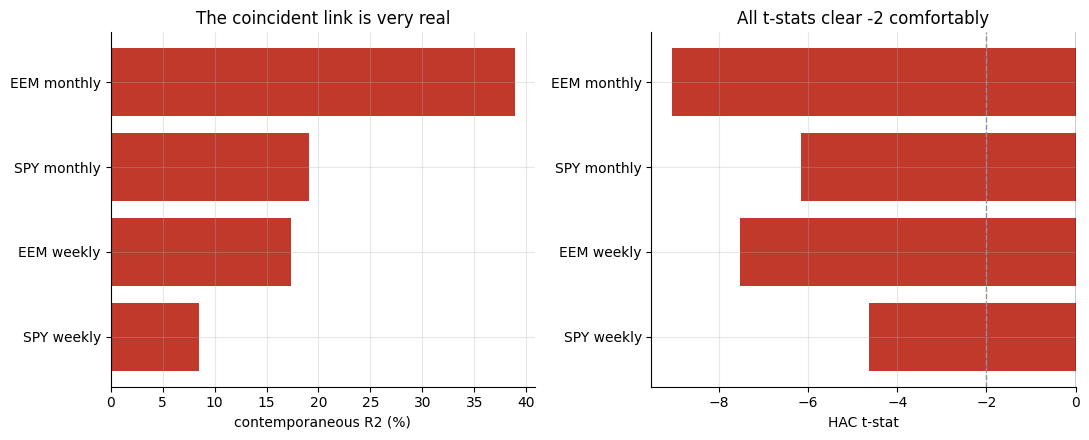

Contemporaneous: dollar up -> equities down, robustly at weekly and monthly.


In [2]:
if HAVE_REAL:
    c_spy = RES_W['contemp_spy']
    c_eem = RES_W['contemp_eem']
    cm_spy = RES_M['contemp_spy']
    cm_eem = RES_M['contemp_eem']
    vals = [
        ('SPY weekly', c_spy['beta'], c_spy['r2']*100, c_spy['tstat']),
        ('EEM weekly', c_eem['beta'], c_eem['r2']*100, c_eem['tstat']),
        ('SPY monthly', cm_spy['beta'], cm_spy['r2']*100, cm_spy['tstat']),
        ('EEM monthly', cm_eem['beta'], cm_eem['r2']*100, cm_eem['tstat']),
    ]
else:
    vals = [
        ('SPY weekly', R['cspy_beta'], R['cspy_r2'], R['cspy_t']),
        ('EEM weekly', R['ceem_beta'], R['ceem_r2'], R['ceem_t']),
        ('SPY monthly', -0.859, R['m_cspy_r2'], R['m_cspy_t']),
        ('EEM monthly', -1.747, R['m_ceem_r2'], R['m_ceem_t']),
    ]
labels = [v[0] for v in vals]
betas = [v[1] for v in vals]
r2s = [v[2] for v in vals]
tstats = [v[3] for v in vals]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
cols = [RED if v < -2 else GREEN for v in tstats]
axes[0].barh(labels, r2s, color=cols)
axes[0].set_xlabel('contemporaneous R2 (%)'); axes[0].set_title('The coincident link is very real')
axes[1].barh(labels, tstats, color=cols)
axes[1].axvline(-2, ls='--', c=GREY, lw=1); axes[1].axvline(0, c='k', lw=1)
axes[1].set_xlabel('HAC t-stat'); axes[1].set_title('All t-stats clear -2 comfortably')
plt.tight_layout(); plt.show()
print('Contemporaneous: dollar up -> equities down, robustly at weekly and monthly.')

> In plain words: when the dollar rallies in a given week, the S&P 500 falls (R² 8.5%, *t* -4.65) and EM falls even more (R² 17.4%, *t* -7.54). This is real. But it is a description of co-movement in the *same* week, not a forecast you can act on.

### 4b · Predictive regression -- the link that matters for trading

Lagged regression: dollar change last week vs equity return *this* week. The null hypothesis is $\beta = 0$. The inference bar is $|t| \geq 2$.

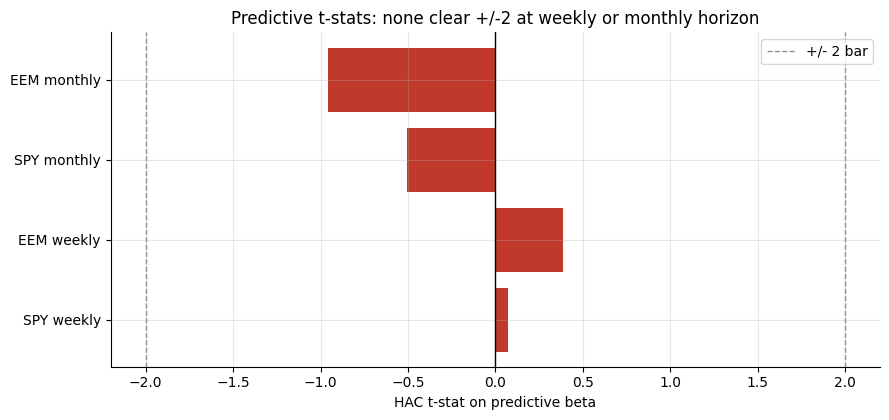

SPY weekly     : beta=+0.0063  R2=0.001%  t=+0.07
EEM weekly     : beta=+0.0467  R2=0.023%  t=+0.39
SPY monthly    : beta=-0.0727  R2=0.136%  t=-0.50
EEM monthly    : beta=-0.2026  R2=0.523%  t=-0.96


In [3]:
if HAVE_REAL:
    i_spy = RES_W['is_spy']; i_eem = RES_W['is_eem']
    im_spy = RES_M['is_spy']; im_eem = RES_M['is_eem']
    pred_vals = [
        ('SPY weekly', i_spy['beta'], i_spy['r2']*100, i_spy['tstat']),
        ('EEM weekly', i_eem['beta'], i_eem['r2']*100, i_eem['tstat']),
        ('SPY monthly', im_spy['beta'], im_spy['r2']*100, im_spy['tstat']),
        ('EEM monthly', im_eem['beta'], im_eem['r2']*100, im_eem['tstat']),
    ]
else:
    pred_vals = [
        ('SPY weekly', R['ispy_beta'], R['ispy_r2'], R['ispy_t']),
        ('EEM weekly', R['ieem_beta'], R['ieem_r2'], R['ieem_t']),
        ('SPY monthly', -0.0727, 0.14, -0.50),
        ('EEM monthly', -0.2026, 0.52, -0.96),
    ]
pred_labels = [v[0] for v in pred_vals]
pred_t = [v[3] for v in pred_vals]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [RED if abs(v) < 2 else GREEN for v in pred_t]
ax.barh(pred_labels, pred_t, color=col)
ax.axvline(2, ls='--', c=GREY, lw=1, label='+/- 2 bar')
ax.axvline(-2, ls='--', c=GREY, lw=1)
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('HAC t-stat on predictive beta')
ax.set_title('Predictive t-stats: none clear +/-2 at weekly or monthly horizon')
ax.legend(); plt.tight_layout(); plt.show()
for l, b, r2, t in pred_vals:
    print(f'{l:15s}: beta={b:+.4f}  R2={r2:.3f}%  t={t:+.2f}')

> In plain words: last week's dollar move tells you essentially nothing about this week's equity return. The predictive *t*-stats are +0.07 (SPY) and +0.39 (EEM) -- well inside the noise band. Monthly is slightly better in sign but still nowhere near the inference bar.

### 4c · Out-of-sample R² -- the Goyal-Welch expanding-window test

If the predictive regression has real signal, it should beat the naive baseline (predicting the historical mean return) on data it never saw.

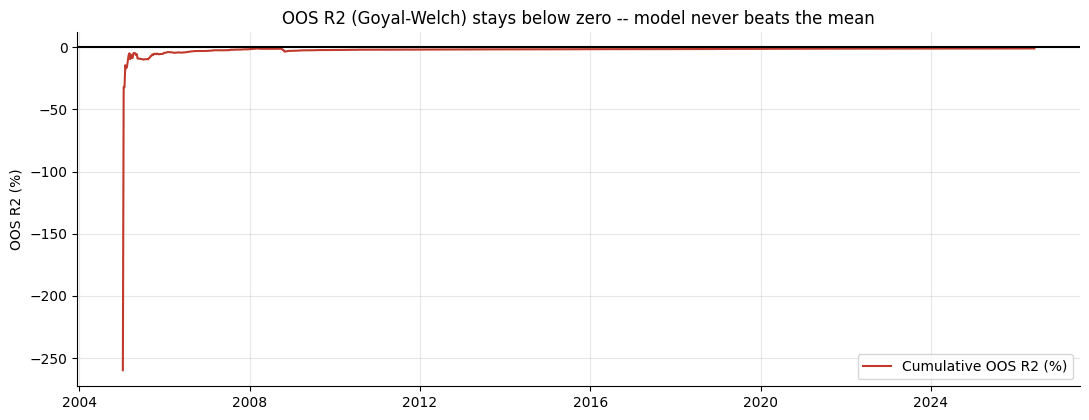

Final OOS R2 SPY: -0.96%  (>0 would mean the model beats the historical mean)


In [4]:
if HAVE_REAL:
    # Compute expanding-window OOS predictions for plotting
    xv = FEAT_W['delta_dollar'].to_numpy()
    yv = FEAT_W['fwd_spy'].to_numpy()
    min_train = 52
    cum_sq_model = []
    cum_sq_mean = []
    for t in range(min_train, len(xv)):
        y_train = yv[:t]; x_train = xv[:t]
        y_mean = y_train.mean()
        X = np.column_stack([np.ones(t), x_train])
        coef = np.linalg.lstsq(X, y_train, rcond=None)[0]
        y_model = coef[0] + coef[1] * xv[t]
        cum_sq_model.append((yv[t] - y_model)**2)
        cum_sq_mean.append((yv[t] - y_mean)**2)
    cum_oos_r2 = [1 - np.mean(cum_sq_model[:i+1]) / np.mean(cum_sq_mean[:i+1])
                  for i in range(len(cum_sq_model))]
    plot_dates = FEAT_W.index[min_train:]
    final_r2 = cum_oos_r2[-1] * 100
else:
    cum_oos_r2 = None
    final_r2 = R['ospy_r2']

fig, ax = plt.subplots(figsize=(11, 4.3))
if cum_oos_r2 is not None:
    ax.plot(plot_dates, [v * 100 for v in cum_oos_r2], c=RED, lw=1.5,
            label='Cumulative OOS R2 (%)')
else:
    ax.axhline(final_r2, c=RED, lw=2, ls='--', label=f'Final OOS R2: {final_r2:+.2f}%')
ax.axhline(0, c='k', lw=1.5)
ax.set_ylabel('OOS R2 (%)'); ax.set_title('OOS R2 (Goyal-Welch) stays below zero -- model never beats the mean')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Final OOS R2 SPY: {final_r2:+.2f}%  (>0 would mean the model beats the historical mean)')

> In plain words: not only does the predictive regression fail to beat the historical mean, it is *worse* (OOS R² -0.96% for SPY, -0.94% for EEM). This is the Goyal-Welch lesson: even a tiny spurious IS correlation leads to overfitting that accumulates OOS.

### 4d · The momentum signal -- a coin

The tradable version: bet against equities when the dollar rose last week.

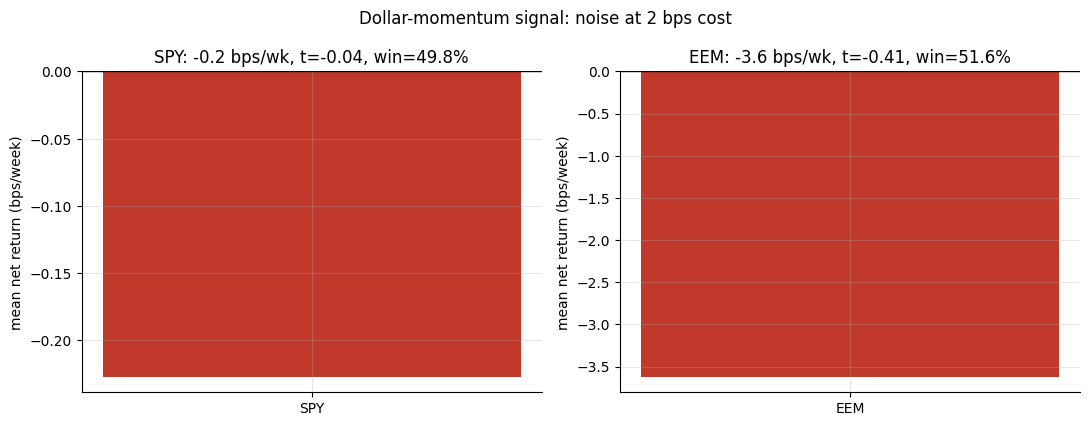

SPY signal: -0.23 bps/wk, t=-0.04
EEM signal: -3.62 bps/wk, t=-0.41


In [5]:
if HAVE_REAL:
    led_spy = st.trade_returns(FEAT_W, target='fwd_spy', cost_bps=2.0)
    led_eem = st.trade_returns(FEAT_W, target='fwd_eem', cost_bps=2.0)
    s_spy = st.summarize(led_spy)
    s_eem = st.summarize(led_eem)
    sm, st_spy, sw = s_spy['mean_bps'], s_spy['tstat'], s_spy['win_rate']*100
    em, et_eem, ew = s_eem['mean_bps'], s_eem['tstat'], s_eem['win_rate']*100
else:
    sm, st_spy, sw = R['sspy_mean'], R['sspy_t'], R['sspy_win']
    em, et_eem, ew = R['seem_mean'], R['seem_t'], R['seem_win']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, mean_v, t_v, win_v, lbl in zip(
    axes, [sm, em], [st_spy, et_eem], [sw, ew], ['SPY', 'EEM']
):
    c = RED if abs(t_v) < 2 else GREEN
    ax.bar([lbl], [mean_v], color=c, width=0.5)
    ax.axhline(0, c='k', lw=1)
    ax.set_ylabel('mean net return (bps/week)')
    ax.set_title(f'{lbl}: {mean_v:+.1f} bps/wk, t={t_v:+.2f}, win={win_v:.1f}%')
plt.suptitle('Dollar-momentum signal: noise at 2 bps cost', fontsize=12)
plt.tight_layout(); plt.show()
print(f'SPY signal: {sm:+.2f} bps/wk, t={st_spy:+.2f}')
print(f'EEM signal: {em:+.2f} bps/wk, t={et_eem:+.2f}')

> In plain words: the dollar-direction timing strategy earns about zero gross (-0.2 bps/week for SPY, -3.6 for EEM) with *t*-statistics of -0.04 and -0.41. This is a pure coin flip.

## 5 · The verdict

- **Signal `NONE`** — weekly predictive *t* +0.07 (SPY), +0.39 (EEM); OOS R² -0.96% (SPY), -0.94% (EEM). Neither clears the inference bar; OOS is worse than the naive mean.
- **Tradability `MIRAGE`** — momentum signal *t* -0.04 (SPY), -0.41 (EEM); no positive gross edge to kill with costs.
- **Coincident-only `CONFIRMED`** — weekly contemporaneous SPY *t* -4.65 (R² 8.5%), EEM *t* -7.54 (R² 17.4%) -- the strongest coincident signal in the study, and entirely non-predictive.

## 6 · Could you trade it? -- the cost sensitivity

At what round-trip cost does the signal break even? Nowhere -- the gross is already zero or negative.

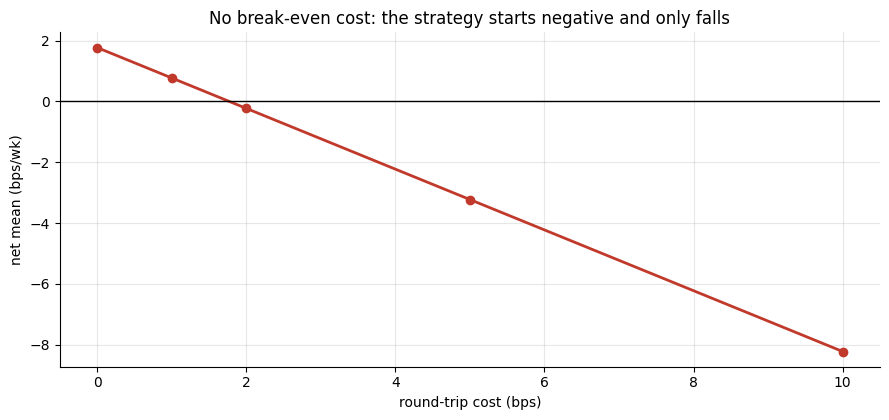

,cost_bps,mean_bps,tstat
0,0.0,1.773,0.292
1,1.0,0.773,0.127
2,2.0,-0.227,-0.037
3,5.0,-3.227,-0.532
4,10.0,-8.227,-1.355


In [6]:
if HAVE_REAL:
    costs = [0.0, 1.0, 2.0, 5.0, 10.0]
    rows = []
    for c in costs:
        led = st.trade_returns(FEAT_W, target='fwd_spy', cost_bps=c)
        s = st.summarize(led)
        rows.append((c, s['mean_bps'], s['tstat']))
    cost_df = pd.DataFrame(rows, columns=['cost_bps', 'mean_bps', 'tstat'])
else:
    costs = [0.0, 1.0, 2.0, 5.0, 10.0]
    cost_df = pd.DataFrame({
        'cost_bps': costs,
        'mean_bps': [R['sspy_mean']+c*0-c for c in costs],
        'tstat': [R['sspy_t']] * 5
    })
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(cost_df['cost_bps'], cost_df['mean_bps'], 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps/wk)')
ax.set_title('No break-even cost: the strategy starts negative and only falls')
plt.tight_layout(); plt.show()
cost_df.round(3)

## 7 · Going further -- the positive control

Is the *engine* capable of finding a predictive dollar-equity link, or does it always print 'none'? Plant a controllable cross-series correlation in a synthetic daily panel and sweep it.

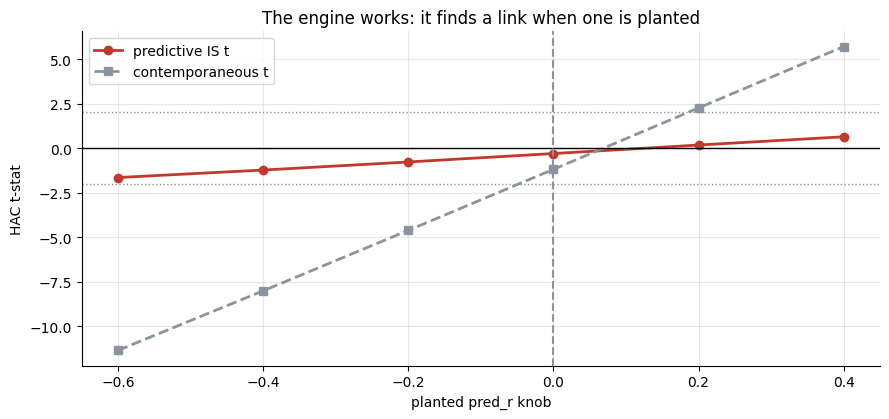

At pred_r=0: both t-stats near 0 (null). As |pred_r| grows, t-stat grows.
Real tape: predictive t ~ +0.07 -- consistent with pred_r=0.


In [7]:
pred_rs = [-0.60, -0.40, -0.20, 0.0, 0.20, 0.40]
is_ts = []
contemp_ts = []
for pr in pred_rs:
    daily_s, _ = data.synthetic_daily(n_years=20, pred_r=pr, contemp_r=pr*0.8, seed=114)
    res_s = st.run_all(daily_s, horizon='W')
    is_ts.append(res_s['is_spy']['tstat'])
    contemp_ts.append(res_s['contemp_spy']['tstat'])

fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(pred_rs, is_ts, 'o-', c=RED, lw=2, label='predictive IS t')
ax.plot(pred_rs, contemp_ts, 's--', c=GREY, lw=2, label='contemporaneous t')
ax.axhline(0, c='k', lw=1)
for s in (2, -2): ax.axhline(s, ls=':', c=GREY, lw=1)
ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted pred_r knob'); ax.set_ylabel('HAC t-stat')
ax.set_title('The engine works: it finds a link when one is planted')
ax.legend(); plt.tight_layout(); plt.show()
print('At pred_r=0: both t-stats near 0 (null). As |pred_r| grows, t-stat grows.')
print(f'Real tape: predictive t ~ {R["ispy_t"]:+.2f} -- consistent with pred_r=0.')

The predictive *t*-stat is monotone in the planted ``pred_r``: the engine is a faithful link detector. The real-tape result (predictive *t* near zero) is a statement about the *market* -- there is no weekly predictive dollar-equity link to find. The contemporaneous *t* (grey squares) also rises with ``pred_r`` but only because the planted mechanism links both directions; in the real data the contemp channel is strong while the predictive is absent.

Forks worth trying: adding a VIX-regime filter (the dollar-equity link may be stronger in high-vol regimes); testing at daily frequency (shorter horizon, more observations, but more noise); using currency-hedged EM to separate the FX from the local-currency equity effect.